## 1 Regularização de tikhonov

In [53]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Gerar dados
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
X = np.vstack([X, X[:20]])
y = np.hstack([y, y[:20]])

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Classe RBFNet
class RBFNet:
    def __init__(self, n_centers=10, sigma=1.0, lambd=1e-3):
        self.n_centers = n_centers
        self.sigma = sigma
        self.lambd = lambd

    def _rbf(self, X, centers):
        # matriz de ativação
        diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
        return np.exp(-np.sum(diff**2, axis=2) / (2 * self.sigma**2))

    def fit(self, X, y):
        # escolher centros via KMeans
        kmeans = KMeans(n_clusters=self.n_centers, random_state=42)
        kmeans.fit(X)
        self.centers = kmeans.cluster_centers_

        Phi = self._rbf(X, self.centers)

        # Regularização (Ridge)
        I = np.eye(Phi.shape[1])
        self.weights = np.linalg.inv(
            Phi.T @ Phi + self.lambd * I
        ) @ Phi.T @ y

    def predict(self, X):
        Phi = self._rbf(X, self.centers)
        y_pred = Phi @ self.weights
        return (y_pred > 0.5).astype(int)

# 4. Treinar
rbf = RBFNet(n_centers=15, sigma=0.5, lambd=1e-2)
rbf.fit(X_train, y_train)

# 5. Testar
y_pred = rbf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia: {acc:.4f}")

Acurácia: 1.0000


## 2 Remap, RBFNet e SVM

In [54]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

def rbf(X, centers, sigma):
    diff = X[:, None, :] - centers[None, :, :]
    return np.exp(-np.sum(diff**2, axis=2) / (2 * sigma**2))

def poly_rbf_svm(X, y, d=2, C=1.0, sigma=1.0):
    
    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    # 1. Polynomial mapping
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # 2. RBF layer
    q = X_train_poly.shape[1]
    n_centers = min(d * q, len(X_train) // 2)
    
    kmeans = KMeans(n_clusters=n_centers, random_state=42)
    centers = kmeans.fit(X_train_poly).cluster_centers_
    
    Phi_train = rbf(X_train_poly, centers, sigma)
    Phi_test = rbf(X_test_poly, centers, sigma)
    
    # 3. Linear SVM
    svm = LinearSVC(C=C, max_iter=10000)
    svm.fit(Phi_train, y_train)
    
    # 4. Evaluation
    y_pred = svm.predict(Phi_test)
    acc = accuracy_score(y_test, y_pred)
    
    return acc

In [55]:
print(f"Acurácia: {poly_rbf_svm(X, y, d=2, C=1.0, sigma=1.0)*100:.2f}%")

Acurácia: 99.36%


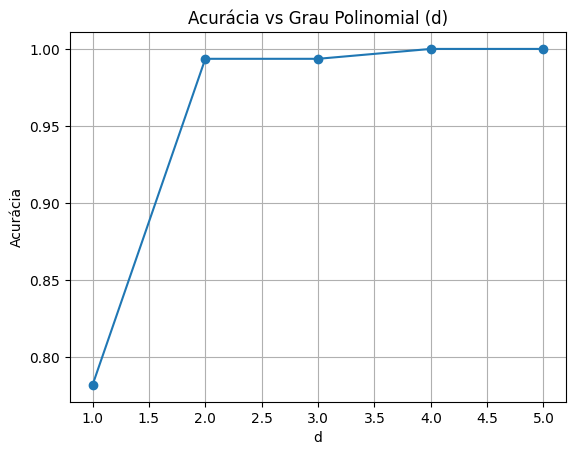

In [56]:
import matplotlib.pyplot as plt

d_values = [1, 2, 3, 4, 5]
acc_values = []

for d in d_values:
    acc = poly_rbf_svm(X, y, d=d, C=1.0, sigma=1.0)
    acc_values.append(acc)

plt.figure()
plt.plot(d_values, acc_values, marker='o')
plt.title("Acurácia vs Grau Polinomial (d)")
plt.xlabel("d")
plt.ylabel("Acurácia")
plt.grid()
plt.show()

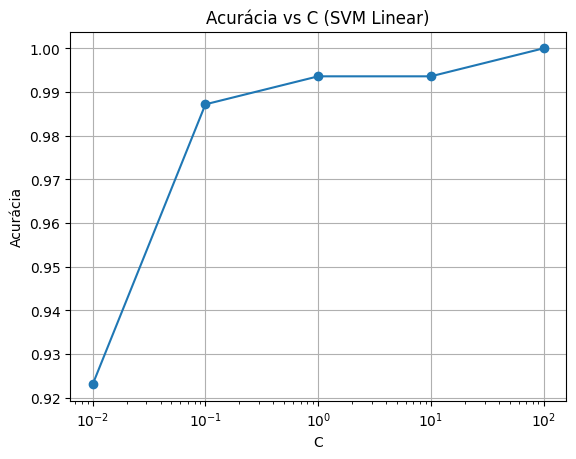

In [57]:
C_values = [0.01, 0.1, 1, 10, 100]
acc_values = []

for C in C_values:
    acc = poly_rbf_svm(X, y, d=2, C=C, sigma=1.0)
    acc_values.append(acc)

plt.figure()
plt.plot(C_values, acc_values, marker='o')
plt.xscale('log')
plt.title("Acurácia vs C (SVM Linear)")
plt.xlabel("C")
plt.ylabel("Acurácia")
plt.grid()
plt.show()

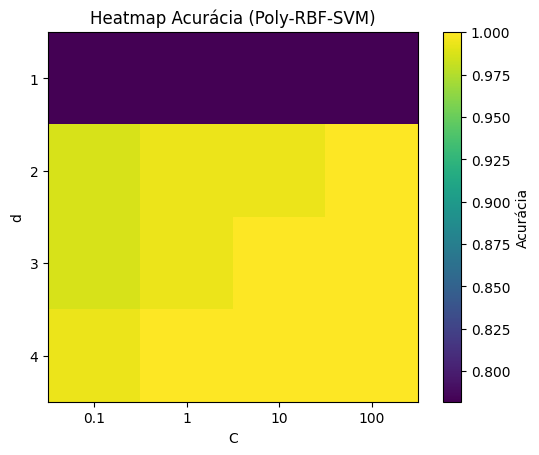

In [58]:
import numpy as np

d_values = [1, 2, 3, 4]
C_values = [0.1, 1, 10, 100]

results = np.zeros((len(d_values), len(C_values)))

for i, d in enumerate(d_values):
    for j, C in enumerate(C_values):
        acc = poly_rbf_svm(X, y, d=d, C=C, sigma=1.0)
        results[i, j] = acc

plt.figure()
plt.imshow(results)
plt.xticks(range(len(C_values)), C_values)
plt.yticks(range(len(d_values)), d_values)
plt.xlabel("C")
plt.ylabel("d")
plt.title("Heatmap Acurácia (Poly-RBF-SVM)")
plt.colorbar(label="Acurácia")
plt.show()

In [59]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def svm_rbf(X, y, C, gamma):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    model = SVC(kernel='rbf', C=C, gamma=gamma)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

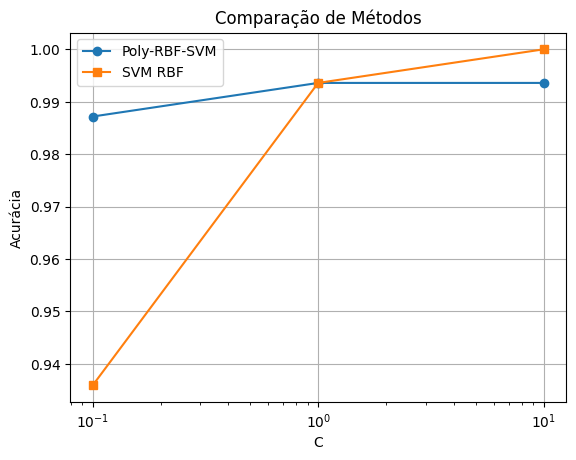

In [60]:
C_values = [0.1, 1, 10]
gamma = 0.5

acc_poly = []
acc_rbf = []

for C in C_values:
    acc_poly.append(poly_rbf_svm(X, y, d=2, C=C, sigma=1.0))
    acc_rbf.append(svm_rbf(X, y, C=C, gamma=gamma))

plt.figure()
plt.plot(C_values, acc_poly, marker='o', label="Poly-RBF-SVM")
plt.plot(C_values, acc_rbf, marker='s', label="SVM RBF")
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Acurácia")
plt.title("Comparação de Métodos")
plt.legend()
plt.grid()
plt.show()

In [61]:
def plot_decision(X, y, model_func):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model_func(grid)
    Z = Z.reshape(xx.shape)
    
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Fronteira de decisão")
    plt.show()

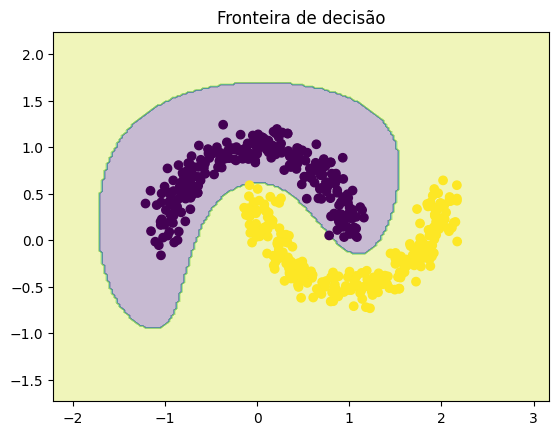

In [62]:
def train_poly_rbf_svm(X, y, d=2, C=1.0, sigma=1.0):
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.cluster import KMeans
    from sklearn.svm import LinearSVC
    from sklearn.model_selection import train_test_split
    
    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    # polynomial
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    
    # RBF
    q = X_train_poly.shape[1]
    n_centers = d * q
    
    kmeans = KMeans(n_clusters=n_centers, random_state=42)
    centers = kmeans.fit(X_train_poly).cluster_centers_
    
    def rbf(X, centers, sigma):
        diff = X[:, None, :] - centers[None, :, :]
        return np.exp(-np.sum(diff**2, axis=2) / (2 * sigma**2))
    
    Phi_train = rbf(X_train_poly, centers, sigma)
    
    # SVM
    svm = LinearSVC(C=C, max_iter=10000)
    svm.fit(Phi_train, y_train)
    
    return poly, centers, svm, sigma, rbf

poly, centers, svm, sigma, rbf = train_poly_rbf_svm(X, y)

plot_decision(
    X, y,
    lambda X_new: svm.predict(
        rbf(poly.transform(X_new), centers, sigma)
    )
)

## 3 Polymap-RBFNet-SVMLin em Wine e Iris


In [63]:
from sklearn.datasets import load_wine, load_iris, make_moons

wine = load_wine()
iris = load_iris()

X_wine, y_wine = wine.data, wine.target
X_iris, y_iris = iris.data, iris.target

X_moons, y_moons = make_moons(n_samples=500, noise=0.1, random_state=42)

In [64]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def svm_rbf(X, y, C, gamma):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    model = SVC(kernel='rbf', C=C, gamma=gamma)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

In [65]:
d_values = [1, 2, 3, 4]
C_values = [0.1, 1, 10, 100]
gamma_values = [0.01, 0.1, 1]

In [66]:
import numpy as np

def run_poly_experiment(X, y):
    results = np.zeros((len(d_values), len(C_values)))
    
    for i, d in enumerate(d_values):
        for j, C in enumerate(C_values):
            acc = poly_rbf_svm(X, y, d=d, C=C, sigma=1.0)
            results[i, j] = acc
    
    return results

In [67]:
def run_rbf_experiment(X, y):
    results = np.zeros((len(C_values), len(gamma_values)))
    
    for i, C in enumerate(C_values):
        for j, g in enumerate(gamma_values):
            acc = svm_rbf(X, y, C=C, gamma=g)
            results[i, j] = acc
    
    return results

In [68]:
res_poly_wine = run_poly_experiment(X_wine, y_wine)
res_rbf_wine = run_rbf_experiment(X_wine, y_wine)

res_poly_iris = run_poly_experiment(X_iris, y_iris)
res_rbf_iris = run_rbf_experiment(X_iris, y_iris)

res_poly_moons = run_poly_experiment(X_moons, y_moons)
res_rbf_moons = run_rbf_experiment(X_moons, y_moons)

In [69]:
import matplotlib.pyplot as plt

def plot_heatmap(results, x_labels, y_labels, title):
    plt.figure()
    plt.imshow(results)
    plt.xticks(range(len(x_labels)), x_labels)
    plt.yticks(range(len(y_labels)), y_labels)
    plt.xlabel("C")
    plt.ylabel("d")
    plt.title(title)
    plt.colorbar(label="Acurácia")
    plt.show()

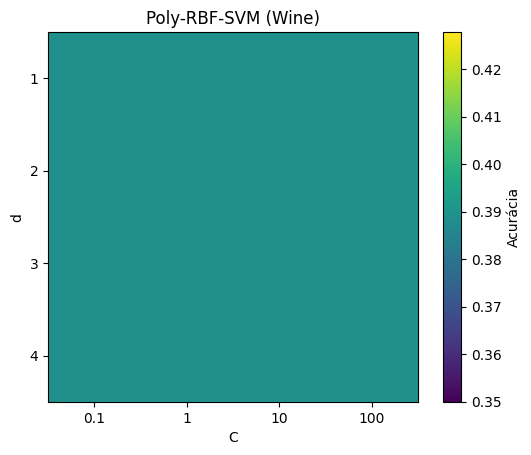

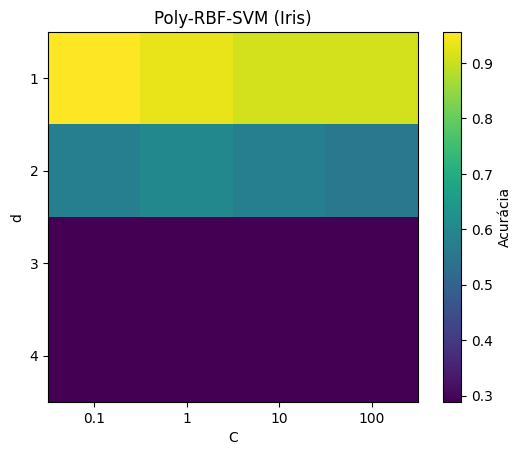

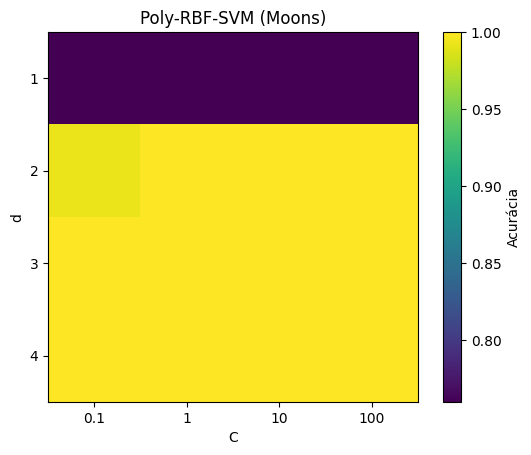

In [70]:
plot_heatmap(res_poly_wine, C_values, d_values, "Poly-RBF-SVM (Wine)")
plot_heatmap(res_poly_iris, C_values, d_values, "Poly-RBF-SVM (Iris)")
plot_heatmap(res_poly_moons, C_values, d_values, "Poly-RBF-SVM (Moons)")

In [71]:
import matplotlib.pyplot as plt

def plot_heatmap(results, x_labels, y_labels, title):
    plt.figure()
    plt.imshow(results)
    plt.xticks(range(len(x_labels)), x_labels)
    plt.yticks(range(len(y_labels)), y_labels)
    plt.xlabel("C")
    plt.ylabel("gamma")
    plt.title(title)
    plt.colorbar(label="Acurácia")
    plt.show()

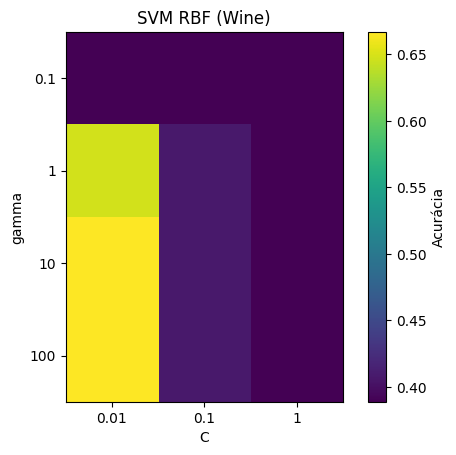

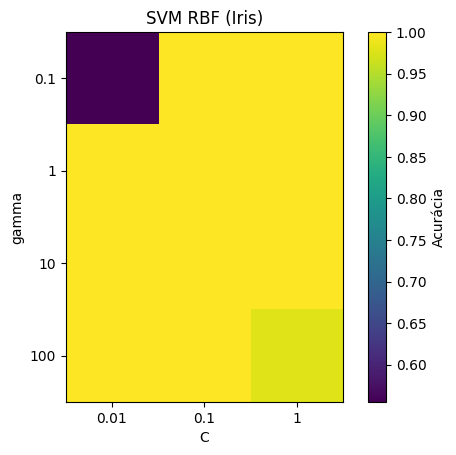

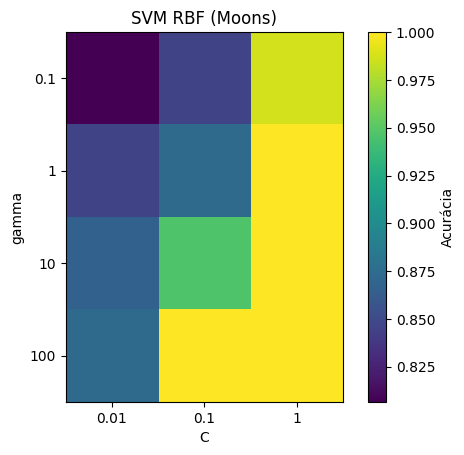

In [72]:
plot_heatmap(res_rbf_wine, gamma_values, C_values, "SVM RBF (Wine)")
plot_heatmap(res_rbf_iris, gamma_values, C_values, "SVM RBF (Iris)")
plot_heatmap(res_rbf_moons, gamma_values, C_values, "SVM RBF (Moons)")

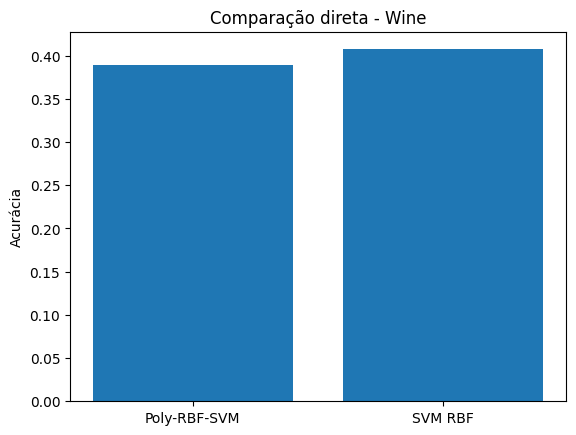

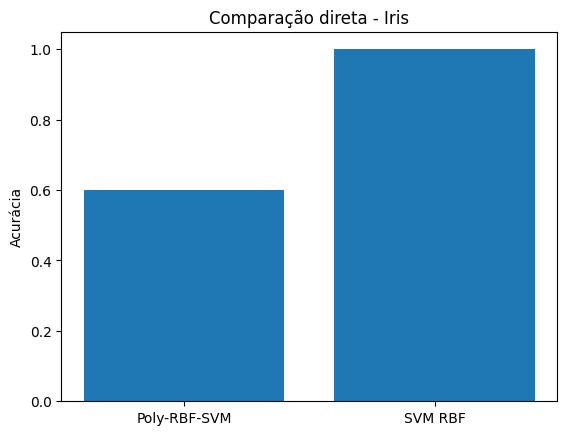

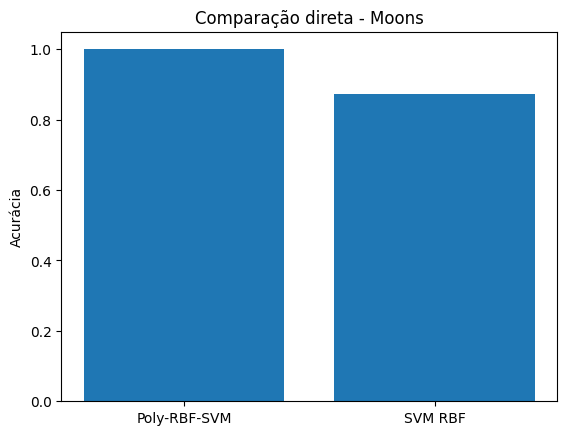

In [73]:
def compare_models(X, y, dataset):
    poly_acc = poly_rbf_svm(X, y, d=2, C=1.0)
    rbf_acc = svm_rbf(X, y, C=1.0, gamma=0.1)
    
    plt.figure()
    plt.bar(["Poly-RBF-SVM", "SVM RBF"], [poly_acc, rbf_acc])
    plt.title(f"Comparação direta - {dataset}")
    plt.ylabel("Acurácia")
    plt.show()
    
compare_models(X_wine, y_wine, "Wine")
compare_models(X_iris, y_iris, "Iris")
compare_models(X_moons, y_moons, "Moons")